## 01 Import Data

### 01-1 Setup Config

In [1]:
from dotenv import load_dotenv
from utils import init_mlflow
import os
import json
import copy
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Set the stock code you want to analyze
STOCK_CODE = 2330

map_dict_path = '/app/data/column_mapping.json'
init_mlflow()
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [2]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math
import time
import mlflow

%matplotlib inline

START_DATE = "2020-01-01"
END_DATE = time.strftime("%Y-%m-%d")

stock_dict_path = '/app/data/top5_stocks_by_category.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))
tqdm.pandas()
mlflow.set_experiment("LSTM_Test")
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

### 01-2 Load Data

In [3]:
[int(x) for x in stock_dict['半導體業']]

[2330, 2408, 2344, 6770, 2337]

In [4]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE stock_code_id = '{stock_code}'
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

def get_stock_data_by_category(category, start_date: str, end_date: str):
    """
    category: 'ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業'
    """
    stock_codes = stock_dict.get(category, [])
    stock_codes = [int(code) for code in stock_codes]
    all_data = []
    for code in stock_codes:
        try:
            df = get_stock_data(code, start_date, end_date)
            all_data.append(df)
        except Exception as e:
            print(f"Error fetching data for stock code {code}: {e}")
    final_df = pd.concat(all_data, ignore_index=True)
    # final_df = final_df.sort_values(by=['date', 'stock_code_id']).reset_index(drop=True)
    return final_df

df = get_stock_data_by_category("半導體業", START_DATE, END_DATE)
df.head()

,date,stock_code_id,market,capacity,turnover,open,high,low,close,change,transaction_volume,close_is_proxy
0,2020-01-02,2330,TWSE,33282120,11224165450,332.5,339.0,332.5,339.0,8.0,17160,False
1,2020-01-03,2330,TWSE,42023268,14295651580,344.0,345.0,335.5,339.5,0.5,20545,False
2,2020-01-06,2330,TWSE,45677057,15210531318,333.0,334.5,332.0,332.0,-7.5,22944,False
3,2020-01-07,2330,TWSE,51746181,17053282011,332.5,333.0,326.5,329.5,-2.5,22362,False
4,2020-01-08,2330,TWSE,37913748,12484410088,325.0,333.0,325.0,329.5,0.0,18228,False


In [5]:
# Fill null values in 'change' using the values from 'change_new' (today's close - yesterday's close)
# df['change_new'] = df['close']-df['close'].shift(1)
# df['change'] = df['change'].fillna(df['change_new'])
# df = df.drop(columns=['change_new'])
df.isnull().sum()

date                  0
stock_code_id         0
market                0
capacity              0
turnover              0
open                  0
high                  0
low                   0
close                 0
change                0
transaction_volume    0
close_is_proxy        0
dtype: int64

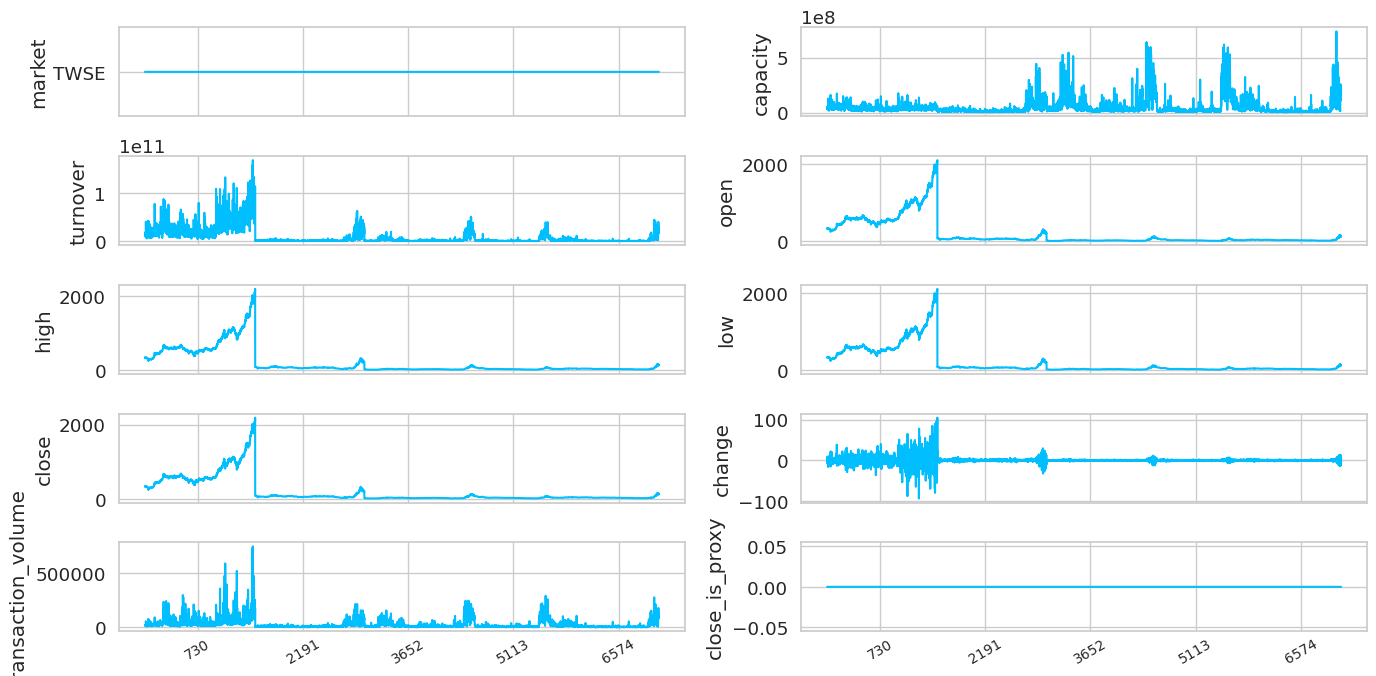

In [6]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['stock_code_id', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [7]:
# Multi-stock feature engineering (4 stocks in the same industry)
train_ratio = 0.9
test_ratio = 1 - train_ratio

# 1) Pick 4 stock codes and align by date
selected_stocks = sorted(df['stock_code_id'].unique())[:4]
print(f"Selected stock codes: {selected_stocks}")

# Keep only required rows/columns and normalize date granularity
df_sub = df[df['stock_code_id'].isin(selected_stocks)].copy()
df_sub['date'] = pd.to_datetime(df_sub['date']).dt.normalize()

# If same stock has duplicate rows on the same date, keep one value by aggregation
dup_cnt = int(df_sub.duplicated(subset=['date', 'stock_code_id']).sum())
if dup_cnt > 0:
    print(f"Found {dup_cnt} duplicate (date, stock_code_id) rows. Aggregating by mean close.")

close_daily = (
    df_sub.groupby(['date', 'stock_code_id'], as_index=False)['close']
    .mean()
    .sort_values(['date', 'stock_code_id'])
)

# Use pivot_table to safely reshape even if duplicates exist
close_wide = (
    close_daily.pivot_table(
        index='date',
        columns='stock_code_id',
        values='close',
        aggfunc='mean',
    )
    .sort_index()
    .ffill()
    .bfill()
)
close_wide.columns = [f"close_{int(code)}" for code in close_wide.columns]

# 2) Build cross-stock features
ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
ret_wide.columns = [f"ret_{col.split('_')[1]}" for col in close_wide.columns]

market_mean_close = close_wide.mean(axis=1).to_frame('market_mean_close')
market_mean_ret = ret_wide.mean(axis=1).to_frame('market_mean_ret')

rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
rel_close.columns = [f"rel_{col}" for col in close_wide.columns]

feature_df = pd.concat(
    [close_wide, ret_wide, market_mean_close, market_mean_ret, rel_close],
    axis=1,
).dropna()

target_cols = ret_wide.columns.tolist()
feature_cols = feature_df.columns.tolist()

# 3) Time-based split (no shuffle): train:test = 9:1
n_total = len(feature_df)
n_train = int(n_total * train_ratio)

df_train = feature_df.iloc[:n_train].copy()
df_test = feature_df.iloc[n_train:].copy()

df_X_train = df_train[feature_cols]
df_X_test = df_test[feature_cols]

df_y_train = df_train[target_cols]
df_y_test = df_test[target_cols]

print(f"Train set: {len(df_X_train)} samples")
print(f"Test set: {len(df_X_test)} samples")
print(f"Target columns: {target_cols}")

Selected stock codes: ['2330', '2337', '2344', '2408']
Train set: 1377 samples
Test set: 153 samples
Target columns: ['ret_2330', 'ret_2337', 'ret_2344', 'ret_2408']


In [8]:
feature_df.columns

Index(['close_2330', 'close_2337', 'close_2344', 'close_2408', 'ret_2330',
       'ret_2337', 'ret_2344', 'ret_2408', 'market_mean_close',
       'market_mean_ret', 'rel_close_2330', 'rel_close_2337', 'rel_close_2344',
       'rel_close_2408'],
      dtype='object')

In [9]:
# Scale features and targets (returns)
x_scaler = MinMaxScaler(feature_range=(0, 1))
df_X_train_scaled = x_scaler.fit_transform(df_X_train.values)
df_X_test_scaled  = x_scaler.transform(df_X_test.values)

y_scaler = MinMaxScaler(feature_range=(0, 1))
df_y_train_scaled = y_scaler.fit_transform(df_y_train.values)
df_y_test_scaled  = y_scaler.transform(df_y_test.values)

ret_scales  = y_scaler.data_max_ - y_scaler.data_min_   # return 的 scaling range
stock_codes = [int(col.split('_')[1]) for col in target_cols]

print('X_train_scaled shape:', df_X_train_scaled.shape)
print('y_train_scaled shape:', df_y_train_scaled.shape)
print('Return scales:', dict(zip(stock_codes, np.round(ret_scales, 6))))
print('Test y scaled (min/max):', df_y_test_scaled.min().round(4), df_y_test_scaled.max().round(4))

X_train_scaled shape: (1377, 14)
y_train_scaled shape: (1377, 4)
Return scales: {2330: np.float64(0.199529), 2337: np.float64(0.314979), 2344: np.float64(0.198958), 2408: np.float64(0.23457)}
Test y scaled (min/max): -0.0052 1.0012


## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [10]:
# Create sequences for multi-stock forecasting
SEQUENCE_LENGTH = 7  # Number of time steps to look back

def create_sequences(X_array, y_array, seq_len):
    X_out, y_out = [], []
    for i in range(len(X_array) - seq_len):
        X_out.append(X_array[i:i + seq_len])
        y_out.append(y_array[i + seq_len])  # shape (4,) — next day only
    return np.array(X_out), np.array(y_out)

X_train_np, y_train_np = create_sequences(df_X_train_scaled, df_y_train_scaled, SEQUENCE_LENGTH)
X_test_np,  y_test_np  = create_sequences(df_X_test_scaled,  df_y_test_scaled,  SEQUENCE_LENGTH)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32)

print('X_train shape:', X_train.shape, 'y_train shape:', y_train.shape)
print('X_test shape:',  X_test.shape,  'y_test shape:',  y_test.shape)

X_train shape: torch.Size([1370, 7, 14]) y_train shape: torch.Size([1370, 4])
X_test shape: torch.Size([146, 7, 14]) y_test shape: torch.Size([146, 4])


In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])  # (batch, n_stocks)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [12]:
# Setup model parameters
params = {
    'input_size':  X_train.shape[2],
    'hidden_size': 64,
    'num_layers':  3,
    'output_size': y_train.shape[1],
    'dropout':     0.3,
}

model     = LSTMModel(**params).to(device)
loss_fn   = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size    = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset  = TensorDataset(X_test, y_test)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

num_epochs         = 100
train_hist         = []
train_rmse_ret_hist = []
rmse_hist_epochs   = []
EVAL_EVERY         = 5   # run full eval every N epochs to avoid redundant passes

def evaluate_metrics(model, data_loader, y_scaler, device):
    """Returns per-stock (rmse, r2) arrays over a data loader."""
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            preds_scaled.append(model(X_batch.to(device)).cpu().numpy())
            trues_scaled.append(y_batch.numpy())  # y_batch is never on GPU
    preds_inv = y_scaler.inverse_transform(np.concatenate(preds_scaled))
    trues_inv = y_scaler.inverse_transform(np.concatenate(trues_scaled))
    rmse = np.sqrt(np.mean((preds_inv - trues_inv) ** 2, axis=0))
    r2   = np.array([r2_score(trues_inv[:, i], preds_inv[:, i])
                     for i in range(trues_inv.shape[1])])
    return rmse, r2

def plot_predictions(true_ret, pred_ret, stock_codes, split_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, i, code in zip(axes.flatten(), range(len(stock_codes)), stock_codes):
        ax.plot(true_ret[:, i], label='Actual Return',    color='blue')
        ax.plot(pred_ret[:, i], label='Predicted Return', color='red', alpha=0.7)
        ax.set_title(f'Stock {code}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Daily Return')
        ax.grid(True)
        ax.legend()
    plt.suptitle(f'{split_name}: Actual vs Predicted Return — one-step-ahead', y=1.02)
    plt.tight_layout()
    plt.show()

best_rmse        = float('inf')
best_model_state = None

with mlflow.start_run(nested=True) as run:
    mlflow.log_params(params)
    for i, code in enumerate(stock_codes):
        mlflow.log_param(f'ret_scale_{code}', float(ret_scales[i]))

    for epoch in range(num_epochs):
        total_loss = 0.0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = loss_fn(model(X_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_hist.append(avg_loss)

        if (epoch + 1) % EVAL_EVERY == 0:
            rmse_by_stock, _ = evaluate_metrics(model, train_loader, y_scaler, device)
            train_rmse_ret   = float(rmse_by_stock.mean())
            train_rmse_ret_hist.append(train_rmse_ret)
            rmse_hist_epochs.append(epoch + 1)

            log_metrics = {'train_mse_scaled': avg_loss, 'train_rmse_ret_avg': train_rmse_ret}
            for idx, code in enumerate(stock_codes):
                log_metrics[f'train_rmse_ret_{code}'] = float(rmse_by_stock[idx])
            mlflow.log_metrics(log_metrics, step=epoch)

            train_msg = ', '.join(f'{code}: {rmse_by_stock[idx]:.4f}'
                                  for idx, code in enumerate(stock_codes))
            print(f'Epoch[{epoch+1}/{num_epochs}] - '
                  f'MSE(scaled): {avg_loss:.4f} - '
                  f'RMSE(ret avg): {train_rmse_ret:.4f} - {train_msg}')

            if train_rmse_ret < best_rmse:
                best_rmse        = train_rmse_ret
                best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)
    print(f'Best Train RMSE (ret avg): {best_rmse:.6f}')
    mlflow.pytorch.log_model(model, name='best_LSTM')

2026/04/26 09:09:49 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/26 09:09:49 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch[5/100] - MSE(scaled): 0.0121 - RMSE(ret avg): 0.0241 - 2330: 0.0189, 2337: 0.0232, 2344: 0.0274, 2408: 0.0268
Epoch[10/100] - MSE(scaled): 0.0119 - RMSE(ret avg): 0.0242 - 2330: 0.0192, 2337: 0.0234, 2344: 0.0274, 2408: 0.0266
Epoch[15/100] - MSE(scaled): 0.0116 - RMSE(ret avg): 0.0241 - 2330: 0.0189, 2337: 0.0232, 2344: 0.0277, 2408: 0.0266
Epoch[20/100] - MSE(scaled): 0.0117 - RMSE(ret avg): 0.0241 - 2330: 0.0188, 2337: 0.0232, 2344: 0.0279, 2408: 0.0266
Epoch[25/100] - MSE(scaled): 0.0117 - RMSE(ret avg): 0.0240 - 2330: 0.0188, 2337: 0.0231, 2344: 0.0274, 2408: 0.0267
Epoch[30/100] - MSE(scaled): 0.0118 - RMSE(ret avg): 0.0241 - 2330: 0.0188, 2337: 0.0235, 2344: 0.0275, 2408: 0.0266
Epoch[35/100] - MSE(scaled): 0.0117 - RMSE(ret avg): 0.0240 - 2330: 0.0189, 2337: 0.0231, 2344: 0.0274, 2408: 0.0266
Epoch[40/100] - MSE(scaled): 0.0116 - RMSE(ret avg): 0.0240 - 2330: 0.0188, 2337: 0.0231, 2344: 0.0275, 2408: 0.0267
Epoch[45/100] - MSE(scaled): 0.0117 - RMSE(ret avg): 0.0240 - 233

2026/04/26 09:10:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/26 09:10:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 09:10:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it

🏃 View run luminous-smelt-14 at: http://172.18.0.3:5000/#/experiments/2/runs/e6eabec6274145509ddf21c155e8a9b4
🧪 View experiment at: http://172.18.0.3:5000/#/experiments/2


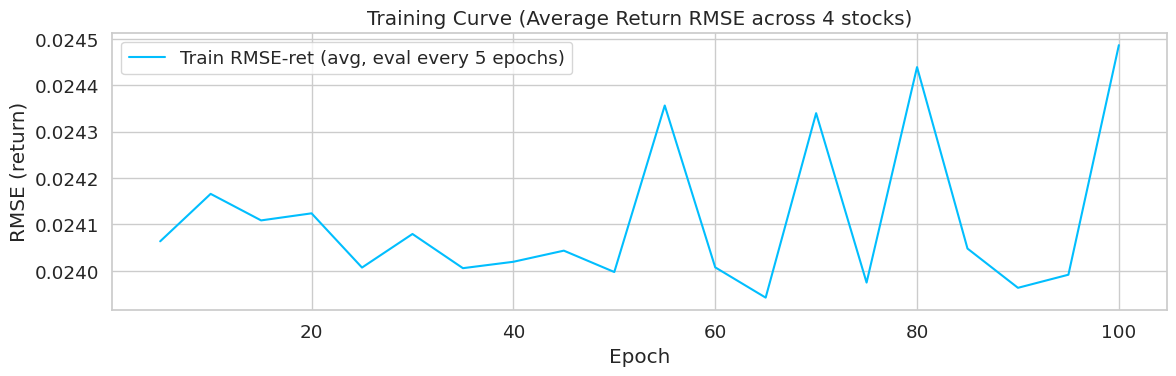

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(rmse_hist_epochs, train_rmse_ret_hist,
         label=f'Train RMSE-ret (avg, eval every {EVAL_EVERY} epochs)')
plt.xlabel('Epoch')
plt.ylabel('RMSE (return)')
plt.legend()
plt.title('Training Curve (Average Return RMSE across 4 stocks)')
plt.tight_layout()
plt.show()

## 03 Forecasting and evaluate

Test metrics by stock (one-step-ahead, return):
  Stock 2330 - RMSE: 0.037033, R²: -2.6571
  Stock 2337 - RMSE: 0.082312, R²: -1.0012
  Stock 2344 - RMSE: 0.062100, R²: -0.4038
  Stock 2408 - RMSE: 0.066798, R²: -0.5706
Average RMSE: 0.062061
Average R²  : -1.1581


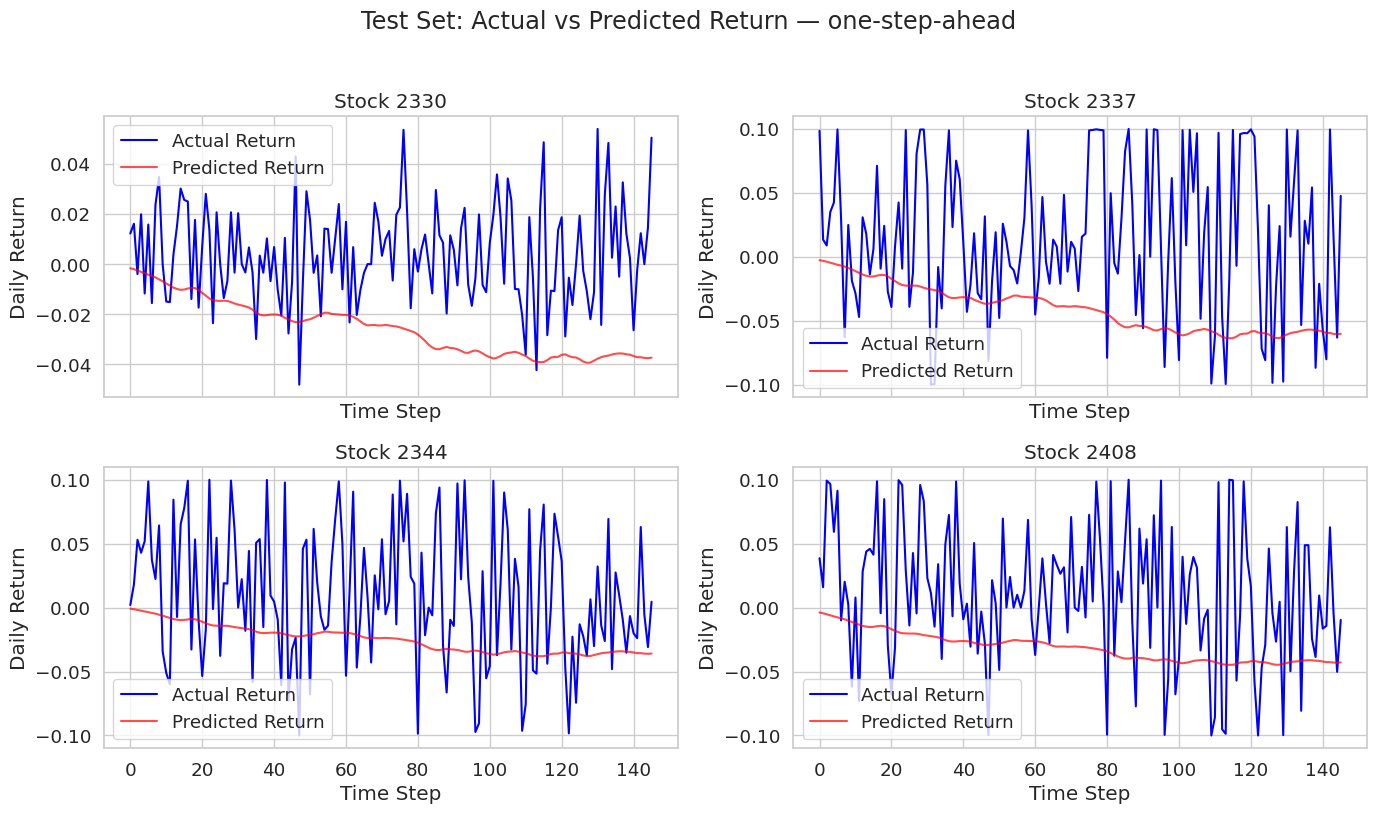


Autoregressive forecast for next 7 days:
  Starting close: {2330: np.float64(2185.0), 2337: np.float64(132.0), 2344: np.float64(88.2), 2408: np.float64(206.0)}
  Day           2330        2337        2344        2408
  Day+1   ret:    -3.73%     -6.02%     -3.59%     -4.29%   price:     2103.4       124.1        85.0       197.2
  Day+2   ret:    -3.71%     -6.00%     -3.58%     -4.28%   price:     2025.3       116.6        82.0       188.7
  Day+3   ret:    -3.68%     -5.98%     -3.55%     -4.25%   price:     1950.9       109.6        79.1       180.7
  Day+4   ret:    -3.62%     -5.92%     -3.50%     -4.20%   price:     1880.3       103.1        76.3       173.1
  Day+5   ret:    -3.55%     -5.85%     -3.44%     -4.14%   price:     1813.5        97.1        73.7       165.9
  Day+6   ret:    -3.42%     -5.66%     -3.32%     -4.02%   price:     1751.4        91.6        71.2       159.3
  Day+7   ret:    -3.09%     -5.09%     -3.00%     -3.70%   price:     1697.3        87.0        6

In [14]:
def recursive_forecast(model, seed_X_scaled, n_steps, y_scaler, last_close, device):
    """
    Autoregressively predicts n_steps days of returns then converts to prices.
    Assumes feature layout: cols [0..n_stocks-1]=close, cols [n_stocks..2*n_stocks-1]=ret
    """
    n_stocks      = y_scaler.n_features_in_
    ret_col_start = n_stocks
    model.eval()
    window = seed_X_scaled.copy()
    current_close_scaled = window[-1, :n_stocks].copy()
    forecasts_scaled = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
            pred_scaled = model(x).cpu().numpy()[0]
            forecasts_scaled.append(pred_scaled)
            window = np.roll(window, -1, axis=0)
            window[-1, ret_col_start:ret_col_start + n_stocks] = pred_scaled
            # 同步更新 close 欄：close_t+1 ≈ close_t × (1 + ret)（在 scaled 空間近似）
            current_close_scaled = current_close_scaled + pred_scaled * current_close_scaled
            current_close_scaled = np.clip(current_close_scaled, 0, 1)
            window[-1, :n_stocks] = current_close_scaled
    rets   = y_scaler.inverse_transform(np.array(forecasts_scaled))
    prices = np.cumprod(1 + rets, axis=0) * last_close
    return rets, prices

# ── Test set evaluation ──────────────────────────────────────────────────────
test_rmse, test_r2 = evaluate_metrics(model, test_loader, y_scaler, device)

# Collect predictions for plotting
model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds_s.append(model(X_b.to(device)).cpu().numpy())
        trues_s.append(y_b.numpy())
test_pred_ret = y_scaler.inverse_transform(np.concatenate(preds_s))
test_true_ret = y_scaler.inverse_transform(np.concatenate(trues_s))

print('Test metrics by stock (one-step-ahead, return):')
for i, code in enumerate(stock_codes):
    print(f'  Stock {code} - RMSE: {test_rmse[i]:.6f}, R²: {test_r2[i]:.4f}')
print(f'Average RMSE: {test_rmse.mean():.6f}')
print(f'Average R²  : {test_r2.mean():.4f}')

plot_predictions(test_true_ret, test_pred_ret, stock_codes, 'Test Set')

# ── Autoregressive 7-day forecast from last test window ──────────────────────
FORECAST_HORIZON = 7
seed       = X_test_np[-1]
last_close = df_test[close_wide.columns].iloc[-1].values

forecast_rets, forecast_prices = recursive_forecast(
    model, seed, FORECAST_HORIZON, y_scaler, last_close, device
)

print(f'\nAutoregressive forecast for next {FORECAST_HORIZON} days:')
print(f'  Starting close: {dict(zip(stock_codes, last_close.round(1)))}')
print(f'  {"Day":<6}  ' + '  '.join(f'{c:>10}' for c in stock_codes))
for day, (rets, prices) in enumerate(zip(forecast_rets, forecast_prices), 1):
    ret_str   = '  '.join(f'{r*100:>+8.2f}%' for r in rets)
    price_str = '  '.join(f'{p:>10.1f}' for p in prices)
    print(f'  Day+{day:<2}  ret: {ret_str}   price: {price_str}')

Autoregressive evaluation over 30 steps (116 windows):

Step  | RMSE_2330  R²_2330 | RMSE_2337  R²_2337 | RMSE_2344  R²_2344 | RMSE_2408  R²_2408
-----------------------------------------------------------------------------------------
Day+1  |  0.0340  -2.393 |  0.0775  -0.971 |  0.0651  -0.441 |  0.0678  -0.629
Day+2  |  0.0339  -2.305 |  0.0771  -0.989 |  0.0651  -0.427 |  0.0677  -0.601
Day+3  |  0.0338  -2.274 |  0.0783  -1.013 |  0.0650  -0.424 |  0.0676  -0.596
Day+4  |  0.0335  -2.200 |  0.0791  -1.019 |  0.0654  -0.431 |  0.0679  -0.611
Day+5  |  0.0330  -2.129 |  0.0794  -1.000 |  0.0654  -0.428 |  0.0672  -0.608
Day+6  |  0.0323  -1.990 |  0.0789  -0.943 |  0.0649  -0.408 |  0.0664  -0.580
Day+7  |  0.0305  -1.604 |  0.0766  -0.832 |  0.0631  -0.349 |  0.0646  -0.502
Day+8  |  0.0279  -1.192 |  0.0721  -0.625 |  0.0619  -0.255 |  0.0632  -0.388
Day+9  |  0.0278  -1.183 |  0.0721  -0.620 |  0.0619  -0.252 |  0.0633  -0.376
Day+10 |  0.0275  -1.196 |  0.0721  -0.581 |  0.0617 

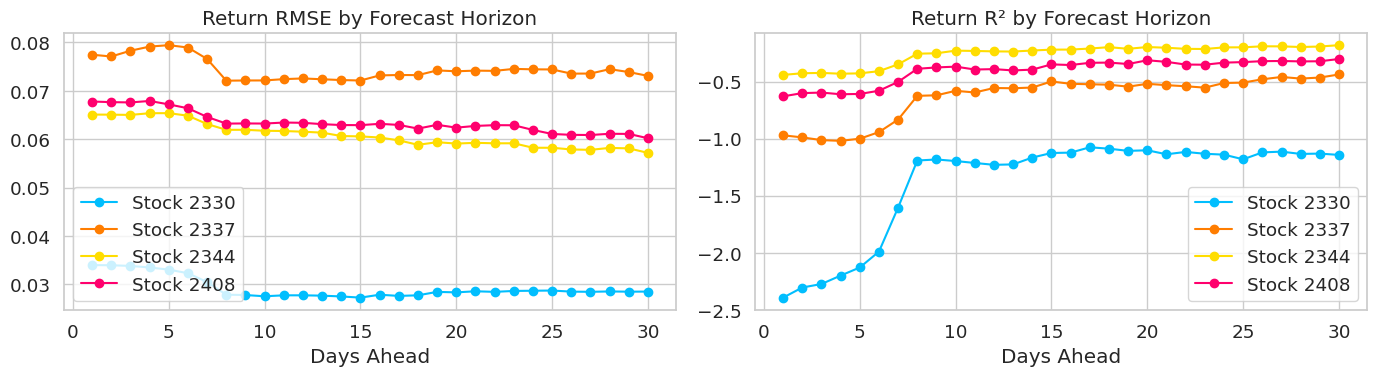

In [15]:
def evaluate_autoregressive_metrics(model, X_test_np, y_test_np, y_scaler,
                                     n_steps, stock_codes, df_test_closes, device):
    """
    Rolling-window backtest：對測試集每個起始點做 n_steps 天自回歸預測，
    計算每個 horizon（day+1 ~ day+n_steps）的 RMSE 和 R²（對 return 計算）。
    """
    n_stocks  = y_scaler.n_features_in_
    seq_len   = X_test_np.shape[1]
    n_windows = len(X_test_np) - n_steps
    if n_windows <= 0:
        raise ValueError(f'Test set too short for {n_steps}-step evaluation.')

    all_preds, all_trues = [], []
    for i in range(n_windows):
        # 取 seed window 最後一天的真實收盤價作為 ret → price 的起始點
        last_close = df_test_closes.iloc[i + seq_len - 1].values
        forecast_rets, _ = recursive_forecast(
            model, X_test_np[i], n_steps, y_scaler, last_close, device
        )
        actual_rets = y_scaler.inverse_transform(y_test_np[i:i + n_steps])
        all_preds.append(forecast_rets)
        all_trues.append(actual_rets)

    all_preds = np.array(all_preds)   # (n_windows, n_steps, n_stocks)
    all_trues = np.array(all_trues)

    rmse_per_step = np.sqrt(np.mean((all_preds - all_trues) ** 2, axis=0))
    r2_per_step   = np.array([
        [r2_score(all_trues[:, step, s], all_preds[:, step, s])
         for s in range(n_stocks)]
        for step in range(n_steps)
    ])

    print(f'Autoregressive evaluation over {n_steps} steps ({n_windows} windows):\n')
    header = 'Step  | ' + ' | '.join(f'RMSE_{c}  R²_{c}' for c in stock_codes)
    print(header)
    print('-' * len(header))
    for step in range(n_steps):
        row = f'Day+{step+1:<2} | '
        row += ' | '.join(
            f'{rmse_per_step[step, s]:7.4f}  {r2_per_step[step, s]:6.3f}'
            for s in range(n_stocks)
        )
        print(row)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    steps = np.arange(1, n_steps + 1)
    for s, code in enumerate(stock_codes):
        axes[0].plot(steps, rmse_per_step[:, s], marker='o', label=f'Stock {code}')
        axes[1].plot(steps, r2_per_step[:, s],   marker='o', label=f'Stock {code}')
    axes[0].set_title('Return RMSE by Forecast Horizon')
    axes[1].set_title('Return R² by Forecast Horizon')
    for ax in axes:
        ax.set_xlabel('Days Ahead')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

    return rmse_per_step, r2_per_step

# 使用
rmse_steps, r2_steps = evaluate_autoregressive_metrics(
    model, X_test_np, y_test_np, y_scaler,
    n_steps=30,
    stock_codes=stock_codes,
    df_test_closes=df_test[close_wide.columns],
    device=device,
)

Train metrics by stock (one-step-ahead, return):
  Stock 2330 - RMSE: 0.018810, R²: 0.0023
  Stock 2337 - RMSE: 0.023030, R²: 0.0031
  Stock 2344 - RMSE: 0.027407, R²: 0.0003
  Stock 2408 - RMSE: 0.026521, R²: 0.0081
Average RMSE: 0.023942
Average R²  : 0.0034


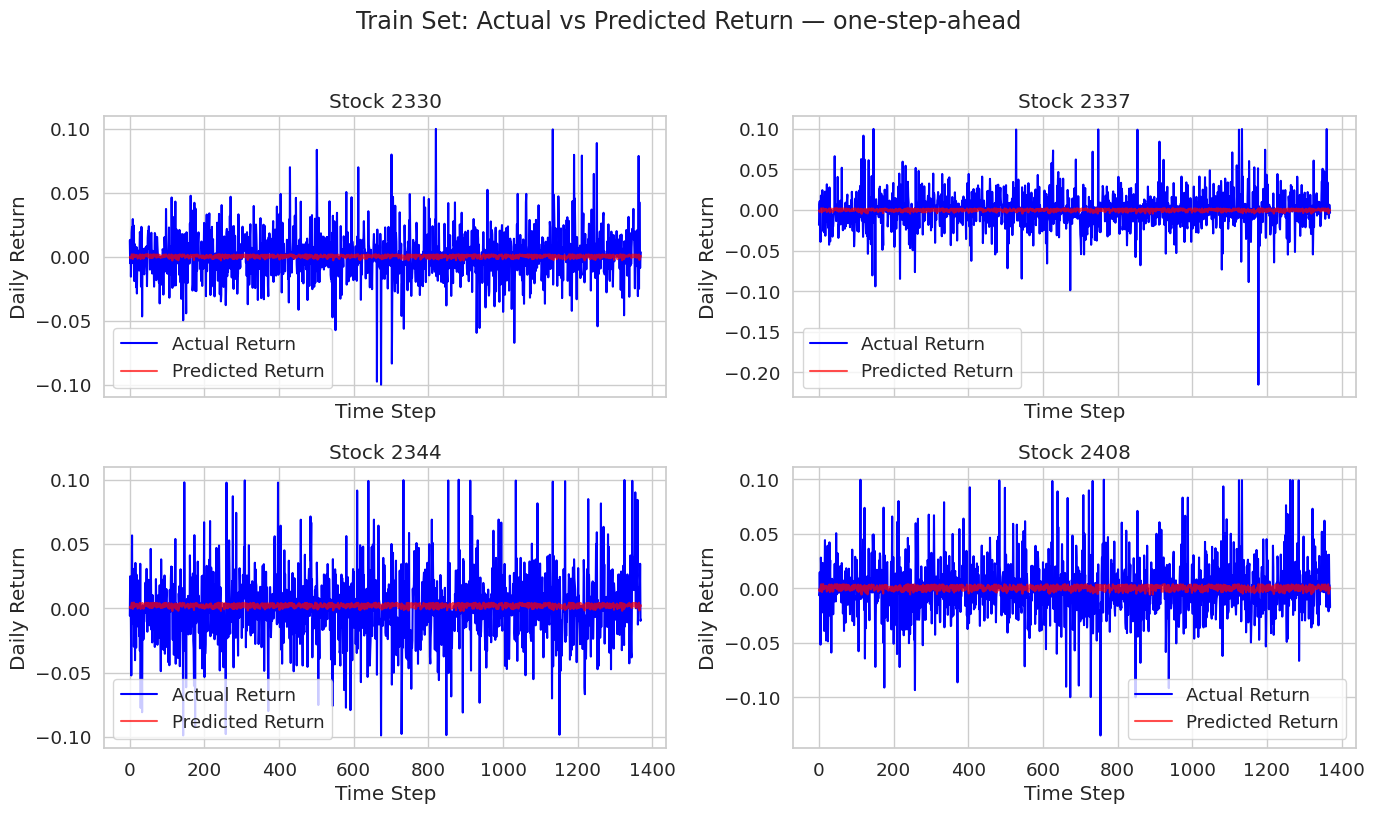

In [16]:
# Train set evaluation
train_rmse, train_r2 = evaluate_metrics(model, train_loader, y_scaler, device)

model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for X_b, y_b in train_loader:
        preds_s.append(model(X_b.to(device)).cpu().numpy())
        trues_s.append(y_b.numpy())
train_pred_ret = y_scaler.inverse_transform(np.concatenate(preds_s))
train_true_ret = y_scaler.inverse_transform(np.concatenate(trues_s))

print('Train metrics by stock (one-step-ahead, return):')
for i, code in enumerate(stock_codes):
    print(f'  Stock {code} - RMSE: {train_rmse[i]:.6f}, R²: {train_r2[i]:.4f}')
print(f'Average RMSE: {train_rmse.mean():.6f}')
print(f'Average R²  : {train_r2.mean():.4f}')

plot_predictions(train_true_ret, train_pred_ret, stock_codes, 'Train Set')

In [17]:
print("Test y scaled (min/max):", df_y_test_scaled.min(), df_y_test_scaled.max())
# 若出現 < 0 或 > 1，代表測試資料超出訓練期範圍

Test y scaled (min/max): -0.005235602094241065 1.0011975043254873


Note: 目前流程改為 Train / Test = 9 : 1，避免將資料再切出 Validation 造成可訓練樣本不足。若後續要做模型選參，建議使用 rolling-window backtesting 取代固定 Validation 切分。

## 04 Save Model

In [18]:
import sqlalchemy
from sqlalchemy import create_engine

# load best model
run_id = run.info.run_id
loaded_model = mlflow.pytorch.load_model(f'runs:/{run_id}/best_LSTM').to(device)

# Prediction the next 7 days
seed = X_test_np[-1]
last_close = df_test[close_wide.columns].iloc[-1].values
_, forecast_prices = recursive_forecast(
    loaded_model,
    seed,
    n_steps=7,
    y_scaler=y_scaler,
    last_close=last_close,
    device=device
)

# Create a DataFrame for the forecasted prices
future_dates = pd.date_range(start=close_wide.index[-1], periods=8)[1:]
forecast_df = pd.DataFrame(
    forecast_prices,
    index = future_dates,
    columns = [f'{code}_pred_price' for code in stock_codes]
)
forecast_df = forecast_df.round(1).astype(int)
forecast_df = forecast_df.reset_index().rename(columns={'index': 'pred_date'})
forecast_df['inference_date'] = time.strftime("%Y-%m-%d")

# Save the forecasted prices to PostgreSQL
engine = create_engine(POSTGRES_URI)
forecast_df.to_sql(
    f"lstm_prediction", 
    con=engine, 
    if_exists='append', 
    index=False
)
print(f"Saved 7-day forecast to PostgreSQL table: lstm_pred_{future_dates[0].strftime('%Y%m%d')}")


Saved 7-day forecast to PostgreSQL table: lstm_pred_20260425


In [19]:
forecast_df

,pred_date,2330_pred_price,2337_pred_price,2344_pred_price,2408_pred_price,inference_date
0,2026-04-25,2103,124,85,197,2026-04-26
1,2026-04-26,2025,116,82,188,2026-04-26
2,2026-04-27,1950,109,79,180,2026-04-26
3,2026-04-28,1880,103,76,173,2026-04-26
4,2026-04-29,1813,97,73,165,2026-04-26
5,2026-04-30,1751,91,71,159,2026-04-26
6,2026-05-01,1697,87,69,153,2026-04-26


In [20]:
# 先看 seed 視窗內的實際報酬率是什麼
seed_date_start = close_wide.index[n_train + len(df_X_test) - SEQUENCE_LENGTH]
seed_date_end   = close_wide.index[n_train + len(df_X_test) - 1]

print("Seed window actual returns:")
print(df_test[target_cols].iloc[-SEQUENCE_LENGTH:].to_string())
print(f"\nSeed period: {seed_date_start.date()} → {seed_date_end.date()}")


Seed window actual returns:
            ret_2330  ret_2337  ret_2344  ret_2408
date                                              
2026-04-16  0.002404 -0.021127 -0.006652  0.009456
2026-04-17 -0.026379 -0.057554 -0.020089 -0.016393
2026-04-20 -0.002463 -0.080153 -0.023918 -0.014286
2026-04-21  0.012346  0.099585  0.063011  0.062802
2026-04-22  0.000000  0.015094 -0.005488 -0.004545
2026-04-23  0.014634 -0.063197 -0.030905 -0.050228
2026-04-24  0.050481  0.047619  0.004556 -0.009615

Seed period: 2026-04-16 → 2026-04-24


## END